# Insulation and peak energy use: a real-world example

This notebook is the runnable companion of the step-by-step tutorial
([HTML version](../docs/tutorial-insulation.html)). It applies the Systems Insight Pipeline
to causal loop diagrams developed in participatory sessions of the
[SEVEN project](https://seven.uva.nl/) at the University of Amsterdam, which studies
household energy decisions. See the SEVEN project's report on this work (Fabian Dablander
and colleagues): <https://seven.uva.nl/en/content/news/2026/03/kgg-report.html>.

Two models are included:

- [`Insulation_PeakEnergy.xlsx`](Insulation_PeakEnergy.xlsx) (used here): what drives the
  *percentage of electricity used during peak hours (16.00-21.00)* at the household level —
  57 variables, 94 links, 21 feedback loops, 51 candidate interventions.
- [`Insulation_Decisions.xlsx`](Insulation_Decisions.xlsx) (alternate): what drives *the
  number of owner-occupiers who insulate to the standard*. Swap the file name below to
  explore it.

## How the raw Kumu export was annotated

1. **Variables of interest**: the peak-hour-use percentage is marked `VOI` in the
   `Description` column. Note the goal is to *lower* it (see `maximize=False` in the
   optimization below).
2. **Intervention variables**: 51 of 57 variables carry `Tags = 1` — everything plausibly
   actionable; only genuine context (e.g., `Regional context`) is excluded.
3. **Time unit and timeframe**: peak-hour consumption shifts year over year → time unit
   *years*; the policy horizon is 15 years.
4. **Classification** (slower than timeframe → constant; faster than time unit → auxiliary;
   in between → stock): 31 stocks (adoption, trust, knowledge — they accumulate) and 26
   constants. The stocks are what make the trajectories below bend and saturate, unlike the
   stock-less [Minimal example](Minimal.ipynb).

> **Defaults**: this model runs entirely on the default equation — each variable a linear
> combination of its incoming links with sampled coefficients (for stocks, the rate of
> change) — the honest choice for a participatory map where only the *signs* of effects were
> elicited. Interventions enter by default: shifting constants' values, stocks' initial
> conditions, and adding to auxiliaries' results.


In [1]:
from sip_systemsinsightpipeline import Extract, SDM, SDMOptimizer, LoopsThatMatter
from sip_systemsinsightpipeline.plots import plot_simulated_intervention_ranking

extract = Extract("Insulation_PeakEnergy.xlsx")
s = extract.extract_settings()

s.seed = 1912884
s.N = 200                       # parameter samples (increase for smoother estimates)
s.t_end = 15                    # years
s.time_unit = "years"
s.parameter_value_aux = 0.3
s.parameter_value_stocks = 0.1

sdm = SDM(s)
voi = s.variable_of_interest[0]

Variable of interest: Percentage of electricity use during peak hours (16.00-21.00) on household level
with 51 intervention variables

21 feedback loops of maximum length 5
All loops have at least one stock
No interaction terms specified so will solve linear SDM.


## Rank interventions under uncertainty

With 51 candidate interventions, the ranking plot is restricted to the strongest 15. Note
that the variable of interest is the share of electricity used during *peak* hours, so
**negative effects are desirable**.

Running Simulations:   0%|          | 0/200 [00:00<?, ?it/s]

Running Simulations:   0%|          | 1/200 [00:00<01:34,  2.11it/s]

Running Simulations:   1%|          | 2/200 [00:00<01:34,  2.09it/s]

Running Simulations:   2%|▏         | 3/200 [00:01<01:42,  1.92it/s]

Running Simulations:   2%|▏         | 4/200 [00:02<01:41,  1.94it/s]

...

Running Simulations:  98%|█████████▊| 197/200 [01:39<00:01,  2.07it/s]

Running Simulations:  99%|█████████▉| 198/200 [01:39<00:00,  2.08it/s]

Running Simulations: 100%|█████████▉| 199/200 [01:39<00:00,  2.09it/s]

Running Simulations: 100%|██████████| 200/200 [01:40<00:00,  2.11it/s]

Running Simulations: 100%|██████████| 200/200 [01:40<00:00,  1.99it/s]

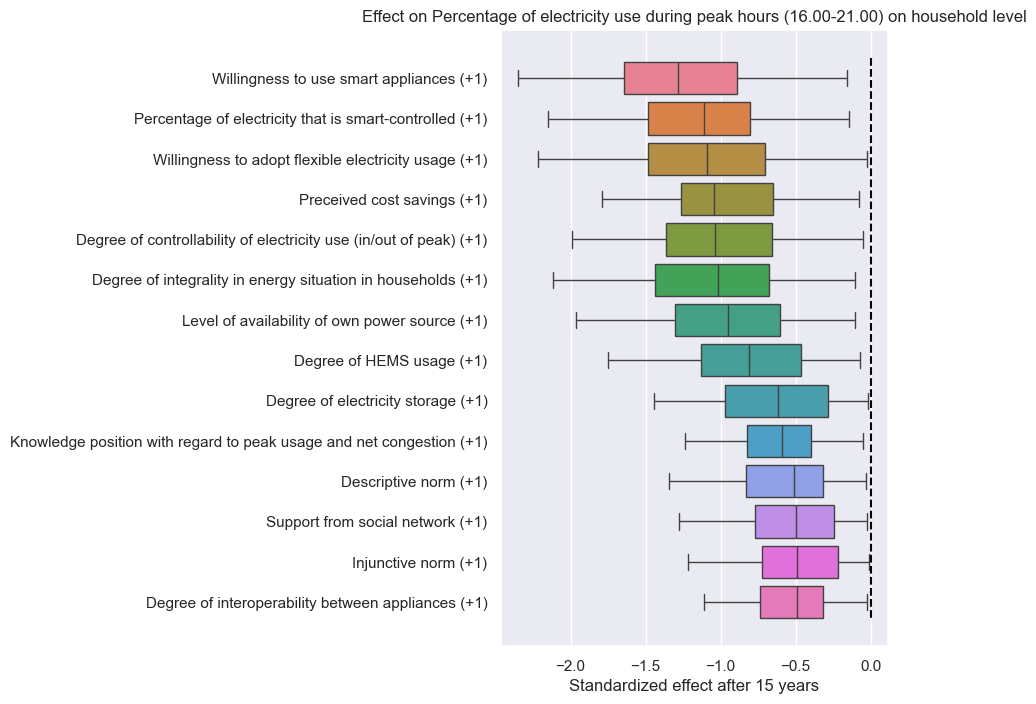

In [2]:
df_sol_per_sample, param_samples = sdm.run_simulations()
intervention_effects = sdm.get_intervention_effects()

fig = plot_simulated_intervention_ranking(s, intervention_effects[voi], voi, top_plot=15)

## Which links drive the outcome?

The sensitivity analysis correlates each sampled link coefficient with the intervention's
effect on the outcome (Spearman rank correlation, with bootstrapped confidence intervals).
Here we analyze the model's top-ranked intervention.

In [3]:
top_intervention = list(intervention_effects[voi].keys())[0]
print("Analyzing intervention:", top_intervention)

SA_results, df_SA = sdm.run_SA(voi, top_intervention, cut_off_SA_importance=0.15, n_bootstraps=100)

Analyzing intervention: Willingness to use smart appliances


+--------------------------------------------------------------------------------------------------------------------------------------+-------+--------------------+------------------+----------------+
|                                                                 Link                                                                 |  Rho  | 95% CI (bootstrap) | Mean Rho per Int | SD Rho per Int |
+--------------------------------------------------------------------------------------------------------------------------------------+-------+--------------------+------------------+----------------+
|        Willingness to use smart appliances->Percentage of electricity use during peak hours (16.00-21.00) on household level         | -0.69 |   [-0.75, -0.63]   |      -0.69       |      0.0       |
|                       Willingness to use smart appliances->Percentage of electricity that is smart-controlled                        | 0.41  |    [0.3, 0.52]     |       0.41       |      0.

## Allocate a budget across all interventions

Rather than picking a single intervention, the optimizer splits a budget across all 51
candidates. Because we want to *reduce* peak-hour electricity use, we set
`maximize=False`.

In [4]:
params = sdm.sample_model_parameters()
costs = [1.0] * len(s.intervention_variables)

optimizer = SDMOptimizer(sdm)
result = optimizer.optimize_intervention_intensities(
    params=params,
    costs=costs,
    variable_of_interest=voi,
    budget=1.0,
    maximize=False,
    n_starts=8,
    seed=1,
)

print("Success:", result["success"])
print("Best effect size:", round(result["best_effect_size"], 4))
print("Near-optimal allocations found:", result["n_equilibria"])

print("\nTop 10 expenditures in the best allocation:")
best = sorted(zip(s.intervention_variables, result["best_y"]), key=lambda kv: -kv[1])
for var, y in best[:10]:
    print(f"  {y:.3f}  {var}")

Success: True
Best effect size: -1.4542
Near-optimal allocations found: 8

Top 10 expenditures in the best allocation:
  0.422  Degree of integrality in energy situation in households
  0.363  Percentage of electricity that is smart-controlled
  0.116  Willingness to use smart appliances
  0.099  Knowledge position with regard to peak usage and net congestion
  0.000  Percentage of electricity usage that is manually directed
  0.000  Average cost of energy storage
  0.000  Degree of trust in unsupervised use of appliances
  0.000  Availability of means to invest in new technology
  0.000  Degree of personal sense of responsibility
  0.000  Degree of controllability of electricity use (in/out of peak)


## How stable is the allocation across parameter uncertainty?

Repeating the optimization for a subset of parameter draws shows which interventions
consistently receive budget. (Each draw runs a 51-dimensional multi-start optimization, so
this cell takes several minutes; increase `n_parameter_samples` for production analyses.)

Optimizing across parameter samples (multistart_slsqp):   0%|          | 0/8 [00:00<?, ?it/s]

Optimizing across parameter samples (multistart_slsqp):  12%|█▎        | 1/8 [00:08<01:02,  8.93s/it]

Optimizing across parameter samples (multistart_slsqp):  25%|██▌       | 2/8 [00:12<00:36,  6.02s/it]

Optimizing across parameter samples (multistart_slsqp):  38%|███▊      | 3/8 [00:20<00:33,  6.61s/it]

Optimizing across parameter samples (multistart_slsqp):  50%|█████     | 4/8 [00:32<00:36,  9.04s/it]

...

Optimizing across parameter samples (multistart_slsqp):  75%|███████▌  | 6/8 [01:31<00:41, 20.58s/it]

Optimizing across parameter samples (multistart_slsqp):  88%|████████▊ | 7/8 [02:08<00:26, 26.19s/it]

Optimizing across parameter samples (multistart_slsqp): 100%|██████████| 8/8 [02:15<00:00, 20.00s/it]

Optimizing across parameter samples (multistart_slsqp): 100%|██████████| 8/8 [02:15<00:00, 16.94s/it]

Text(0.5, 1.0, 'Interventions that consistently receive budget')

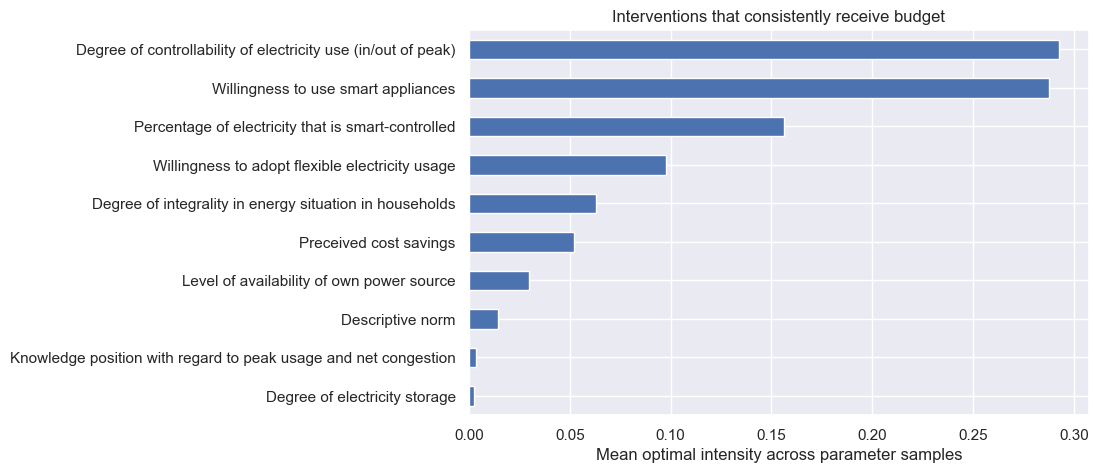

In [5]:
opt_df = optimizer.optimize_across_parameter_samples(
    costs=costs,
    variable_of_interest=voi,
    maximize=False,
    n_parameter_samples=8,
    n_starts=4,
    seed=1,
)

intensity_cols = [c for c in opt_df.columns if c.startswith("intensity_")]
mean_alloc = opt_df[intensity_cols].mean().sort_values(ascending=False)
mean_alloc.index = [c.replace("intensity_", "") for c in mean_alloc.index]

ax = mean_alloc.head(10)[::-1].plot(kind="barh", figsize=(8, 5))
ax.set_xlabel("Mean optimal intensity across parameter samples")
ax.set_title("Interventions that consistently receive budget")

## Which feedback loops dominate the dynamics?

The Loops That Matter (LTM) method (Schoenberg, Davidsen & Eberlein) scores every feedback
loop's contribution to the model's behavior at each point in time.

In [6]:
ltm = LoopsThatMatter(sdm)
ltm.print_loops()

# LTM scores the dynamics of a simulation run; without an intervention this
# model's baseline stays at zero, so analyze the response to the strongest lever
df_sol_ltm, link_scores, loop_scores = ltm.run_ltm_analysis(
    params, n_points=100, intervention_intensities=1.0,
    intervention_variable=top_intervention)
ltm.get_loop_summary()


Identified 300 feedback loops:

  R1 (Reinforcing): Degree of changed usage pattern induction cooking plate → Percentage of electricity usage that is manually directed → Degree of controllability of electricity use (in/out of peak) → Percentage of electricity use during peak hours (16.00-21.00) on household level → Preceived cost savings → Perception of urgency → Willingness to adopt flexible electricity usage → Percentage of electricity that is smart-controlled → Degree of visibility of electricity usage → Descriptive norm → Perception of flexibility in daily routines → Degree of changed usage pattern induction cooking plate
  B1 (Balancing): Degree of changed usage pattern induction cooking plate → Percentage of electricity usage that is manually directed → Degree of controllability of electricity use (in/out of peak) → Percentage of electricity use during peak hours (16.00-21.00) on household level → Preceived cost savings → Perception of urgency → Perception of flexibility in dail

,loop_name,loop_type,loop_variables,mean_relative,max_abs_relative,mean_raw,max_abs_raw,std_relative,n_valid,n_total
0,R1,Reinforcing,Degree of changed usage pattern induction cook...,3.092713e-07,2.670409e-06,2.384155e-06,2.274187e-05,5.991402e-07,99,99
1,B1,Balancing,Degree of changed usage pattern induction cook...,-3.591972e-06,1.891739e-05,-2.642154e-05,1.611052e-04,5.087652e-06,99,99
2,R2,Reinforcing,Degree of changed usage pattern induction cook...,3.604192e-11,3.854724e-10,2.825662e-10,3.282780e-09,7.960717e-11,99,99
3,R3,Reinforcing,Degree of changed usage pattern induction cook...,2.226295e-08,1.831106e-07,1.708437e-07,1.559416e-06,4.174007e-08,99,99
4,R4,Reinforcing,Degree of changed usage pattern induction cook...,4.664599e-11,5.003736e-10,3.657920e-10,4.261307e-09,1.032313e-10,99,99
...,...,...,...,...,...,...,...,...,...,...
295,R158,Reinforcing,Willingness to adopt flexible electricity usag...,1.030492e-02,2.859872e-02,6.754270e-02,2.435539e-01,8.448665e-03,99,99
296,B139,Balancing,Willingness to adopt flexible electricity usag...,-1.224538e-03,4.516428e-03,-8.556617e-03,3.846304e-02,1.324740e-03,99,99
297,B140,Balancing,Willingness to adopt flexible electricity usag...,-2.186145e-06,1.008539e-05,-1.580701e-05,8.588968e-05,2.816010e-06,99,99
298,B141,Balancing,Willingness to adopt flexible electricity usag...,-2.084019e-04,7.779299e-04,-1.459904e-03,6.625046e-03,2.280817e-04,99,99


## Next steps

- Edit the Excel file: add or remove links, change which variables are tagged as
  interventions, or add a custom `Equation` column entry to make a relationship nonlinear,
  then re-run this notebook.
- See the [README](../README.md) for the full API and Excel format documentation, and the
  D2D paper (Uleman et al., arXiv:2508.05659) for the methodology behind simulating causal
  loop diagrams under uncertainty.